### **Section 1 - Import Libraries**

In [1]:
#%pip install grad-cam

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve
)
import sys
import os
from torch.utils.data import ConcatDataset

### **Section 2 - Load Project Path**

In [2]:
# Add project root folder to Python path

sys.path.append(
    "/Users/manish/Documents/GitHub/leaf-based-water-stress-detection"
)

print("Project path added successfully")

Project path added successfully


### **Section 3 - Pipeline Configuration**

In [3]:
from src.data_loader import *
from src.evaluate import *
from src.models import *
from src.train import *
from src.transforms import *
from src.gradcam import *
print("Files Imported Successfully")

Train Shape: (9580, 48, 48, 3)
Validation Shape: (2395, 48, 48, 3)
Test Shape: (6065, 48, 48, 3)
Unique Labels: [0 1 2]
Converted Train Labels: [0 1]
Converted Validation Labels: [0 1]
Converted Test Labels: [0 1]
Train Label Distribution:
[3200 6380]
Validation Label Distribution:
[ 875 1520]
Test Label Distribution:
[2245 3820]
Tomato Images: 20955
Maize Images: 400
Tomato Labels: [0 1]
Maize Labels: [0 1]
Tomato Train: 14668
Tomato Validation: 3143
Tomato Test: 3144
Maize Train: 280
Maize Validation: 60
Maize Test: 60
Using Apple GPU (MPS)
Feature Extractors Created
Files Imported Successfully


### **Section 4 - Create All Models**

In [4]:
tomato_model = create_model()
maize_model = create_model()
maize2_model = create_model()

improved_tomato_model = create_model()
improved_maize_model = create_model()
improved_maize2_model = create_model()

fusion_model = FusionModel().to(device)

dg_model = DomainGeneralisationModel(num_domains=3).to(device)

print("Models Created Successfully")


Models Created Successfully


### **Section 5 - Load All Saved Models**

In [5]:
saved = "../Notebooks/saved_models"

# Baseline Ensemble Models
tomato_model.load_state_dict(
    torch.load(os.path.join(saved, "tomato_model.pth"), map_location=device)
)
tomato_model.eval()

maize_model.load_state_dict(
    torch.load(os.path.join(saved, "maize_model.pth"), map_location=device)
)
maize_model.eval()

maize2_model.load_state_dict(
    torch.load(os.path.join(saved, "maize2_model.pth"), map_location=device)
)
maize2_model.eval()

# Improved Ensemble Models
improved_tomato_model.load_state_dict(
    torch.load(os.path.join(saved, "improved_tomato_model.pth"), map_location=device)
)
improved_tomato_model.eval()

improved_maize_model.load_state_dict(
    torch.load(os.path.join(saved, "improved_maize_model.pth"), map_location=device)
)
improved_maize_model.eval()

improved_maize2_model.load_state_dict(
    torch.load(os.path.join(saved, "improved_maize2_model.pth"), map_location=device)
)
improved_maize2_model.eval()

# Fusion Model
fusion_model.load_state_dict(
    torch.load(os.path.join(saved, "fusion_model.pth"), map_location=device)
)
fusion_model.eval()

# Domain Generalization Model
dg_model.load_state_dict(
    torch.load(os.path.join(saved, "dg_model.pth"), map_location=device)
)
dg_model.eval()

print("All trained weights loaded. Models are ready for evaluation.")

All trained weights loaded. Models are ready for evaluation.


### **Section 6 - Create Datasets and Dataloaders**

In [6]:
batch_size = 32

# Merged test dataset for Ensemble evaluation
merged_test_data = (
    test_tomato_data +
    test_maize_data +
    list(test_maize2_data)
)
merged_test_labels = (
    list(test_tomato_labels) +
    list(test_maize_labels) +
    list(test_maize2_labels)
)
merged_test_dataset = LeafDataset(
    merged_test_data, merged_test_labels, transform
)

# Individual test loaders for Fusion evaluation
fusion_batch_size = 16

fusion_tomato_test_loader = DataLoader(
    LeafDataset(test_tomato_data, test_tomato_labels, transform),
    batch_size=fusion_batch_size, shuffle=False, drop_last=True
)
fusion_maize_test_loader = DataLoader(
    LeafDataset(test_maize_data, test_maize_labels, transform),
    batch_size=fusion_batch_size, shuffle=False, drop_last=True
)
fusion_maize2_test_loader = DataLoader(
    LeafDataset(list(test_maize2_data), list(test_maize2_labels), transform),
    batch_size=fusion_batch_size, shuffle=False, drop_last=True
)

# DG test loader

dg_batch_size = 32

dg_tomato_test = DomainLeafDataset(
    test_tomato_data, test_tomato_labels,
    domain_id=0, transform=dg_val_transform
)
dg_maize_test = DomainLeafDataset(
    test_maize_data, test_maize_labels,
    domain_id=1, transform=dg_val_transform
)
dg_maize2_test = DomainLeafDataset(
    list(test_maize2_data), list(test_maize2_labels),
    domain_id=2, transform=dg_val_transform
)
dg_test_combined = ConcatDataset([
    dg_tomato_test, dg_maize_test, dg_maize2_test
])
dg_test_loader = DataLoader(
    dg_test_combined,
    batch_size=dg_batch_size, shuffle=False,
    num_workers=0, pin_memory=True
)

# Individual test loaders for per-model evaluation
tomato_test_loader = DataLoader(
    LeafDataset(test_tomato_data, test_tomato_labels, transform),
    batch_size=batch_size, shuffle=False
)
maize_test_loader = DataLoader(
    LeafDataset(test_maize_data, test_maize_labels, transform),
    batch_size=batch_size, shuffle=False
)
maize2_test_loader = DataLoader(
    LeafDataset(list(test_maize2_data), list(test_maize2_labels), transform),
    batch_size=batch_size, shuffle=False
)

print("All datasets and dataloaders  created.")

All datasets and dataloaders  created.


### **Section 7 - Collect Ensemble Prediction and Probabilities**

In [9]:
ens_preds = []
ens_labels = []
ens_probs = []

tomato_model.eval()
maize_model.eval()
maize2_model.eval()

with torch.no_grad():

    for image, label in merged_test_dataset:

        tensor = image.unsqueeze(0).to(device)

        p1 = torch.softmax(tomato_model(tensor), dim=1)
        p2 = torch.softmax(maize_model(tensor), dim=1)
        p3 = torch.softmax(maize2_model(tensor), dim=1)

        avg_prob = (p1 + p2 + p3) / 3

        stress_prob = avg_prob[0, 1].item()

        pred = torch.argmax(
            avg_prob,
            dim=1
        ).item()

        ens_preds.append(pred)
        ens_labels.append(label)
        ens_probs.append(stress_prob)

ens_preds = np.array(ens_preds)
ens_labels = np.array(ens_labels)
ens_probs = np.array(ens_probs)

### **Section 8 - Ensemble Model Evaluation**


------------------------------
Ensemble Model Evaluation
------------------------------
Ensemble Model Accuracy : 71.43%
 ROC-AUC : 0.7037 - Overall separability (1.0 = perfect, 0.5 = random)

                precision    recall  f1-score   support

Non-Stress (0)     0.8961    0.1571    0.2673      3075
    Stress (1)     0.7031    0.9910    0.8226      6194

      accuracy                         0.7143      9269
     macro avg     0.7996    0.5740    0.5449      9269
  weighted avg     0.7671    0.7143    0.6384      9269



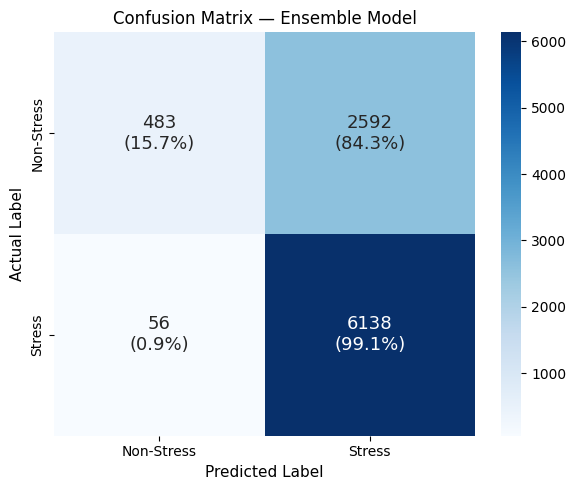

In [10]:
print("\n" + "-"*30)
print("Ensemble Model Evaluation")
print("-"*30)

ensemble_accuracy = evaluate_ensemble(
    merged_test_dataset,
    tomato_model,
    maize_model,
    maize2_model,
    device
)

# Metrics
ens_auc = compute_all_metrics(
    ens_preds,
    ens_labels,
    ens_probs,
    model_name="Ensemble Model (MobileNetV2)"
)

plot_confusion_matrix(
    ens_preds,
    ens_labels,
    "Ensemble Model"
)

ens_roc_data = {
    "name": "Ensemble",
    "labels": ens_labels,
    "probs": ens_probs,
    "auc": ens_auc
}

### **Section 9 - Collect Improved Ensemble Prediction and Probabilities**

In [11]:
imp_ens_preds = []
imp_ens_labels = []
imp_ens_probs = []

improved_tomato_model.eval()
improved_maize_model.eval()
improved_maize2_model.eval()

with torch.no_grad():

    for image, label in merged_test_dataset:

        tensor = image.unsqueeze(0).to(device)

        p1 = torch.softmax(improved_tomato_model(tensor), dim=1)
        p2 = torch.softmax(improved_maize_model(tensor), dim=1)
        p3 = torch.softmax(improved_maize2_model(tensor), dim=1)

        # Weighted averaging
        avg_prob = (
            0.5 * p1 +
            0.3 * p2 +
            0.2 * p3
        )

        stress_prob = avg_prob[0, 1].item()

        pred = torch.argmax(
            avg_prob,
            dim=1
        ).item()

        imp_ens_preds.append(pred)
        imp_ens_labels.append(label)
        imp_ens_probs.append(stress_prob)

imp_ens_preds = np.array(imp_ens_preds)
imp_ens_labels = np.array(imp_ens_labels)
imp_ens_probs = np.array(imp_ens_probs)

### **Section 10 - Improved Ensemble Model Evaluation**


------------------------------
Improved Ensemble Model Evaluation
------------------------------
Improved Ensemble Model Accuracy : 75.40%
 ROC-AUC : 0.9446 - Overall separability (1.0 = perfect, 0.5 = random)

                precision    recall  f1-score   support

Non-Stress (0)     0.9553    0.2712    0.4225      3075
    Stress (1)     0.7331    0.9937    0.8437      6194

      accuracy                         0.7540      9269
     macro avg     0.8442    0.6325    0.6331      9269
  weighted avg     0.8068    0.7540    0.7040      9269



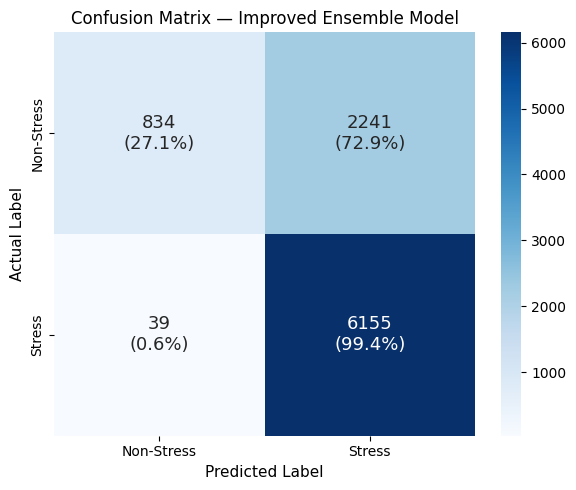

In [12]:
print("\n" + "-"*30)
print("Improved Ensemble Model Evaluation")
print("-"*30)

improved_ensemble_accuracy = evaluate_improved_ensemble(
    merged_test_dataset,
    improved_tomato_model,
    improved_maize_model,
    improved_maize2_model,
    device
)

# Metrics
imp_ens_auc = compute_all_metrics(
    imp_ens_preds,
    imp_ens_labels,
    imp_ens_probs,
    model_name="Improved Ensemble Model"
)

plot_confusion_matrix(
    imp_ens_preds,
    imp_ens_labels,
    "Improved Ensemble Model"
)

imp_ens_roc_data = {
    "name": "Improved Ensemble",
    "labels": imp_ens_labels,
    "probs": imp_ens_probs,
    "auc": imp_ens_auc
}

### **Section 11 - Feature Fusion Model Evaluation**


------------------------------
Feature Fusion Model Evaluation
------------------------------
 ROC-AUC : 1.0000 - Overall separability (1.0 = perfect, 0.5 = random)

                precision    recall  f1-score   support

Non-Stress (0)     1.0000    1.0000    1.0000        11
    Stress (1)     1.0000    1.0000    1.0000        37

      accuracy                         1.0000        48
     macro avg     1.0000    1.0000    1.0000        48
  weighted avg     1.0000    1.0000    1.0000        48



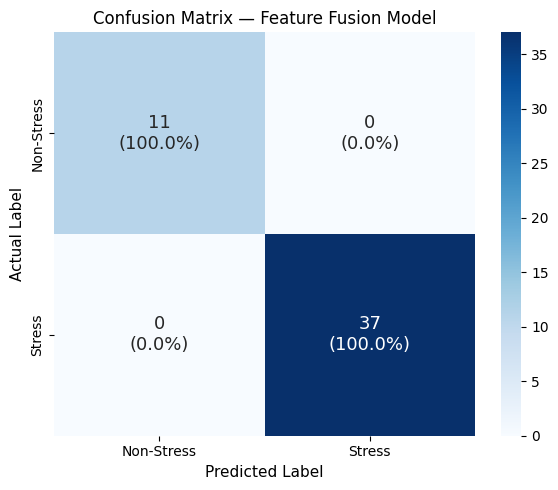

In [13]:
print("\n" + "-"*30)
print("Feature Fusion Model Evaluation")
print("-"*30)

fusion_preds, fusion_labels, fusion_probs = collect_predictions_fusion(
    fusion_model,
    fusion_tomato_test_loader,
    fusion_maize_test_loader,
    fusion_maize2_test_loader,
    device
)

fusion_auc = compute_all_metrics(
    fusion_preds, fusion_labels, fusion_probs,
    model_name="Feature Fusion Model (3-stream MobileNetV2)"
)

plot_confusion_matrix(fusion_preds, fusion_labels, "Feature Fusion Model")

fusion_roc_data = {"name": "Feature Fusion", "labels": fusion_labels,
                   "probs": fusion_probs, "auc": fusion_auc}


### **Section 12 - Collect probabilities for Domain Generalization**

In [7]:
dg_probs = []
dg_model.eval()

with torch.no_grad():
    for images, stress_labels, domain_labels in dg_test_loader:
        images = images.to(device)
        stress_out, _ = dg_model(images)

        probs = torch.softmax(
            stress_out,
            dim=1
        )
        
        stress_prob = probs[:, 1]
        dg_probs.extend(
            stress_prob.cpu().numpy()
        )

dg_probs = np.array(dg_probs)


/Users/manish/Library/r-miniconda-arm64/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


### **Section 13 - Domain Generalization Model Evaluation**


------------------------------
Domain Generalisation Model Evaluation
------------------------------
  Domain Generalisation Test Accuracy: 97.32%

Per-Domain Accuracy:
  Tomato              : 99.97%  (3143/3144)
  Maize (folder)      : 91.67%  (55/60)
  Maize2 (.npy)       : 96.01%  (5823/6065)
 ROC-AUC : 0.9950 - Overall separability (1.0 = perfect, 0.5 = random)

                precision    recall  f1-score   support

Non-Stress (0)     0.9509    0.9694    0.9601      3075
    Stress (1)     0.9847    0.9751    0.9799      6194

      accuracy                         0.9732      9269
     macro avg     0.9678    0.9723    0.9700      9269
  weighted avg     0.9735    0.9732    0.9733      9269



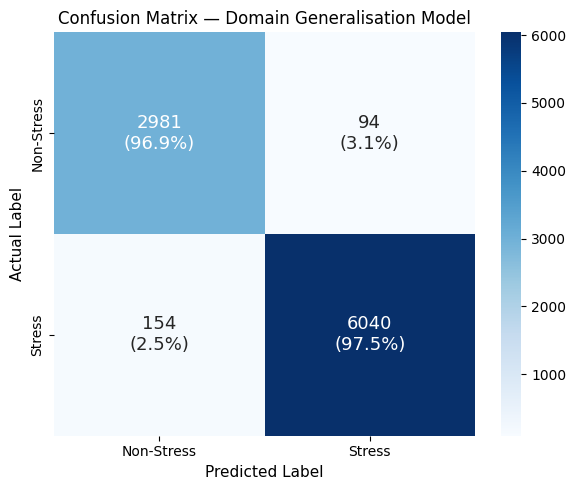

In [8]:
print("\n" + "-"*30)
print("Domain Generalisation Model Evaluation")
print("-"*30)

dg_accuracy, dg_preds, dg_labels, dg_domains = evaluate_dg_model(
    dg_model,
    dg_test_loader,
    device,
    dataset_name="Domain Generalisation"
)

# Metrics
dg_auc = compute_all_metrics(
    dg_preds,
    dg_labels,
    dg_probs,
    model_name="Domain Generalisation Model (DANN)"
)

plot_confusion_matrix(
    dg_preds,
    dg_labels,
    "Domain Generalisation Model"
)

dg_roc_data = {
    "name": "DANN",
    "labels": dg_labels,
    "probs": dg_probs,
    "auc": dg_auc
}

In [ ]:
# Convert to numpy
dg_preds_np   = np.array(dg_preds)
dg_labels_np  = np.array(dg_labels)
dg_domains_np = np.array(dg_domains)

domain_names = {
    0: "Tomato  (D1)",
    1: "Maize   (D2)",
    2: "Maize2  (D3)"
}

print("\n" + "="*60)
print("Per-Domain Evaluation — DANN Model")
print("="*60)

for domain_id, domain_name in domain_names.items():

    idx = dg_domains_np == domain_id
    true = dg_labels_np[idx]
    preds = dg_preds_np[idx]

    acc = 100 * np.sum(true == preds) / len(true)

    print(f"\nDomain : {domain_name}  ({len(true)} test samples)")
    print(f"Accuracy : {acc:.2f}%")
    print()
    print(classification_report(
        true, preds,
        target_names=['Non-stress', 'Stress'],
        digits=4
    ))


Per-Domain Evaluation — DANN Model

Domain : Tomato  (D1)  (3144 test samples)
Accuracy : 99.97%

              precision    recall  f1-score   support

  Non-stress     0.9988    1.0000    0.9994       815
      Stress     1.0000    0.9996    0.9998      2329

    accuracy                         0.9997      3144
   macro avg     0.9994    0.9998    0.9996      3144
weighted avg     0.9997    0.9997    0.9997      3144


Domain : Maize   (D2)  (60 test samples)
Accuracy : 91.67%

              precision    recall  f1-score   support

  Non-stress     0.7500    1.0000    0.8571        15
      Stress     1.0000    0.8889    0.9412        45

    accuracy                         0.9167        60
   macro avg     0.8750    0.9444    0.8992        60
weighted avg     0.9375    0.9167    0.9202        60


Domain : Maize2  (D3)  (6065 test samples)
Accuracy : 96.01%

              precision    recall  f1-score   support

  Non-stress     0.9356    0.9581    0.9467      2245
      Stress  

### **Section 14 - ROC Curve Comparision Between All Models**

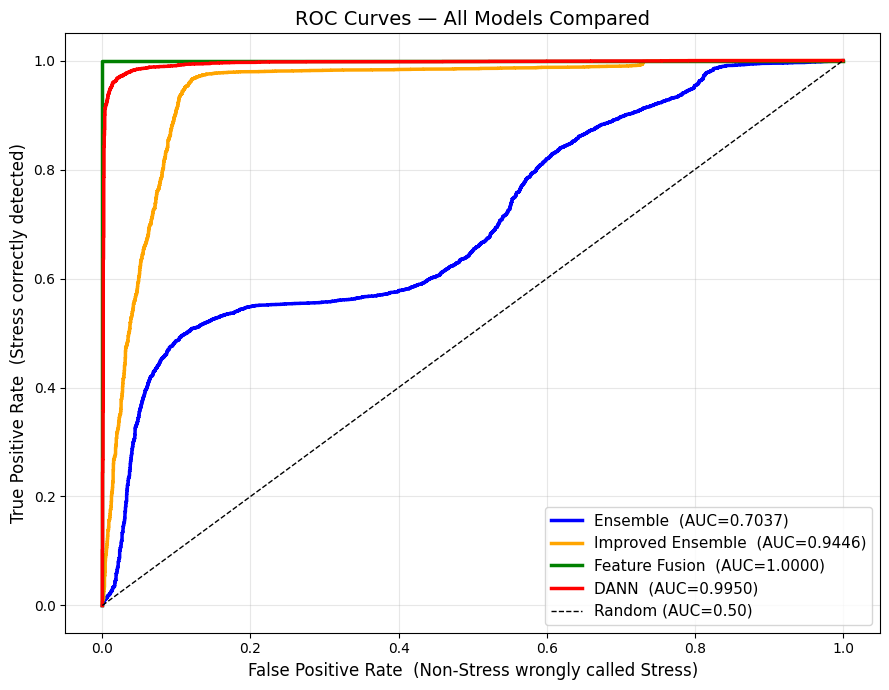

In [16]:
# Plotting all models on the same ROC graph lets visually compare them.
# The model whose curve is furthest towards the top-left corner is the best.

plot_roc_curves([
    ens_roc_data,
    imp_ens_roc_data,
    fusion_roc_data,
    dg_roc_data
])

### **Section 16 - Grad-Cam Visulization**

In [12]:
dg_target_layer = dg_model.feature_extractor[18][0]

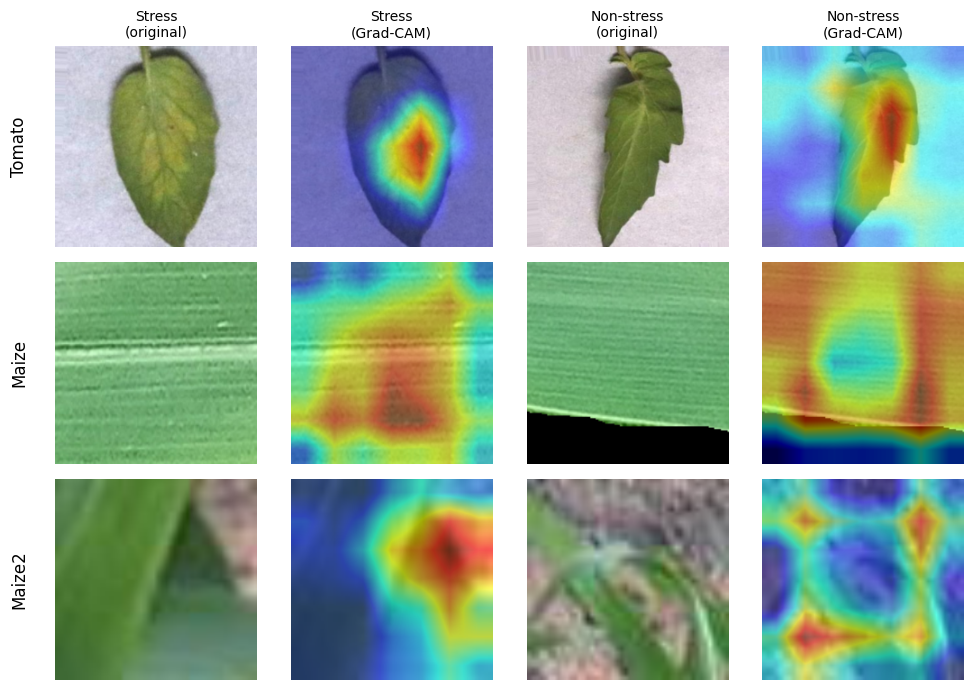

In [14]:
domain_images = {
    "Tomato": good_pair(
        dg_model,
        test_tomato_data,
        test_tomato_labels,
        dg_val_transform,
        device
    ),

    "Maize": good_pair(
        dg_model,
        test_maize_data,
        test_maize_labels,
        dg_val_transform,
        device
    ),

    "Maize2": good_pair(
        dg_model,
        test_maize2_data,
        test_maize2_labels,
        dg_val_transform,
        device
    )
}

generate_gradcam(
    dg_model,
    dg_target_layer,
    domain_images,
    dg_val_transform,
    device,
)